In [1]:
!pip install torch torchvision timm pillow

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------- ----------------- 0.8/1.4 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 4.5 MB/s  0:00:00
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.5/124.1 MB 4.2 MB/s eta 0:00:30
   ---------------------------------------- 1.3/124.1 MB 3.5 MB/s eta 0:00:35
    --------------------------------------- 2.4/124.1 MB 3.9 MB/s eta 0:00:31
   - -------------------------------------- 3.1/124.1 MB 3.8 MB/s eta 0:00:33
   - -------------------------------------- 3.7/124.1 MB 3.7 MB/s eta 0:00:33
   - -------------------------------------- 4.5/124.1 MB 3.6 MB/s eta 0:00:34
   - -------------------------------------- 5.2/124.1 MB 3.6 MB/s eta 0:00:33
   - -------------------------------------- 6.0/124.1 MB 3.6 MB/s eta 0:00:33
   -- ------------------------------------- 6.6/124.1 MB 3.6 MB/s eta 0:00:33
   -- ---


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   -------------------- -------------------  6/12 [torch]
   -------------------- -------------------  6/12 [torch]
   -------------------- -------------------  6/12 [torch]
   -------------------- -------------------  6/12 [torch]
   -------------------- -------------------  6/12 [torch]
   -------------------- -------------------  6/12 [torch]
   -------------------- -------------------  6/12 [torch]
   -------------------- -------------------  6/12 [torch]
   -------------------- -------------------  6/12 [torch]
   -------------------- -------------------  6/12 [torch]
   -------------------- -------------------  6/12 [torch]
   -------------------- -------------------  6/12 [torch]
   -------------------- -------------------  6/12 [torch]
   -------------------- -------------------  6/12 [torch]
   -------------------- -------------------  6/12 [torch]
   -------------------- -------------------  6/12 [torch]
   -------------------- -------------------  6/12 [torch]
   -----------

Using device: cpu
Model loaded successfully!

Processing 6 sample images...



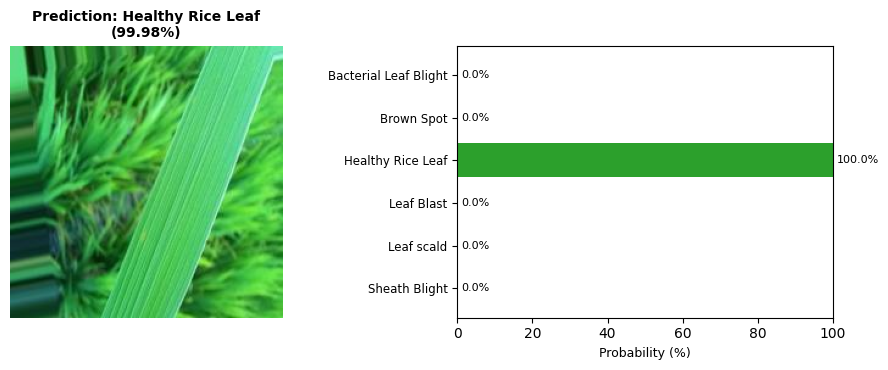

[1/6] Image: healthy.jpg
Diagnosis : Healthy Rice Leaf
Confidence: 99.98%
------------------------------------------------
  Bacterial Leaf Blight   : 0.01%
  Brown Spot              : 0.00%
  Healthy Rice Leaf       : 99.98%
  Leaf Blast              : 0.00%
  Leaf scald              : 0.00%
  Sheath Blight           : 0.00%



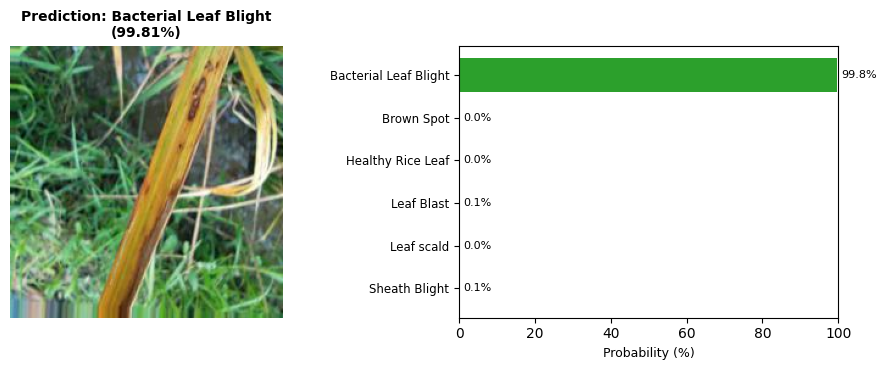

[2/6] Image: bacterial.jpg
Diagnosis : Bacterial Leaf Blight
Confidence: 99.81%
------------------------------------------------
  Bacterial Leaf Blight   : 99.81%
  Brown Spot              : 0.01%
  Healthy Rice Leaf       : 0.01%
  Leaf Blast              : 0.05%
  Leaf scald              : 0.03%
  Sheath Blight           : 0.09%



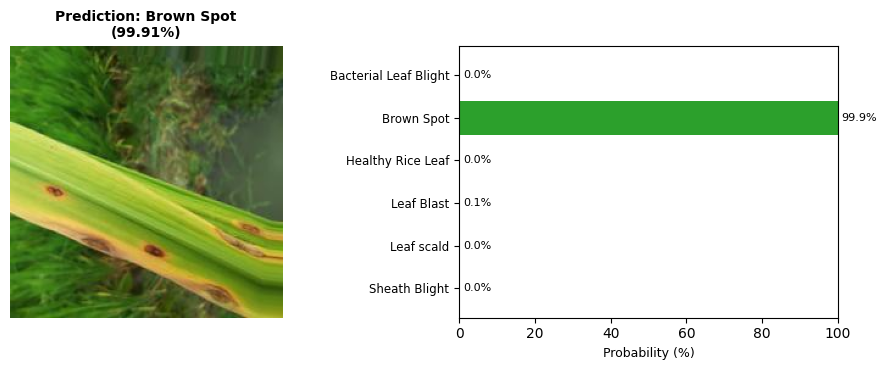

[3/6] Image: brownspot.jpg
Diagnosis : Brown Spot
Confidence: 99.91%
------------------------------------------------
  Bacterial Leaf Blight   : 0.01%
  Brown Spot              : 99.91%
  Healthy Rice Leaf       : 0.00%
  Leaf Blast              : 0.07%
  Leaf scald              : 0.01%
  Sheath Blight           : 0.00%



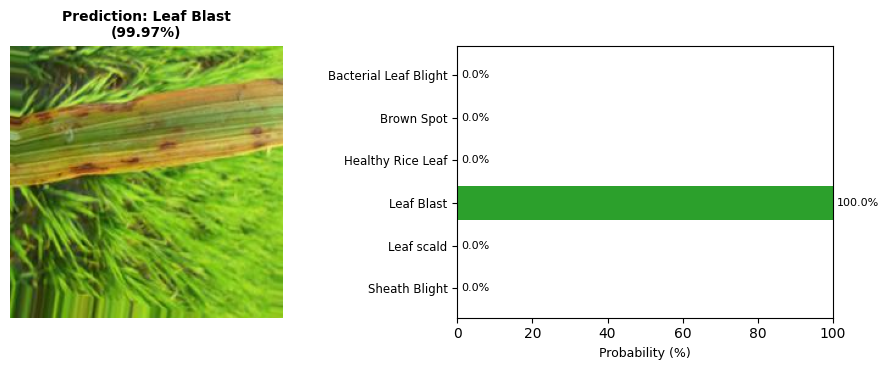

[4/6] Image: leafblast.jpg
Diagnosis : Leaf Blast
Confidence: 99.97%
------------------------------------------------
  Bacterial Leaf Blight   : 0.01%
  Brown Spot              : 0.01%
  Healthy Rice Leaf       : 0.00%
  Leaf Blast              : 99.97%
  Leaf scald              : 0.00%
  Sheath Blight           : 0.00%



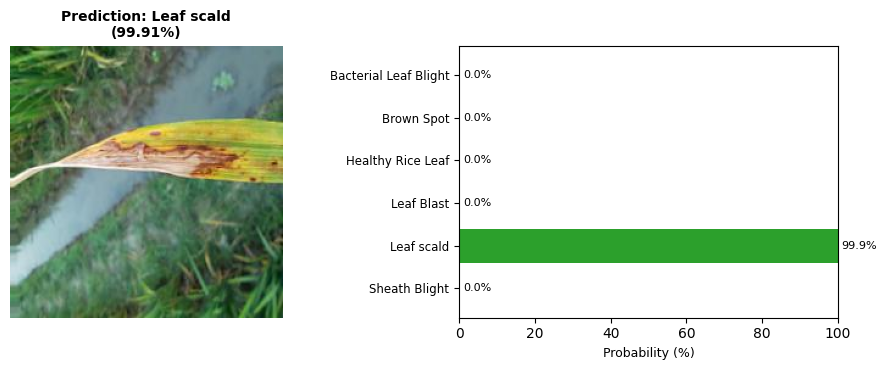

[5/6] Image: leafscald.jpg
Diagnosis : Leaf scald
Confidence: 99.91%
------------------------------------------------
  Bacterial Leaf Blight   : 0.00%
  Brown Spot              : 0.04%
  Healthy Rice Leaf       : 0.01%
  Leaf Blast              : 0.03%
  Leaf scald              : 99.91%
  Sheath Blight           : 0.00%



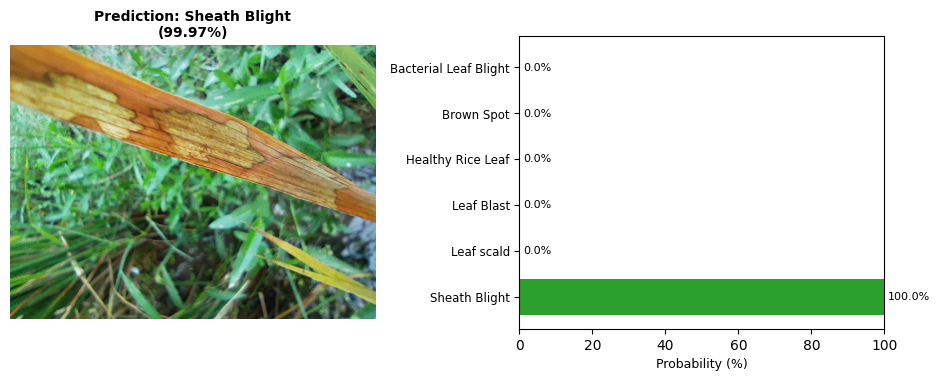

[6/6] Image: sheathblight.jpg
Diagnosis : Sheath Blight
Confidence: 99.97%
------------------------------------------------
  Bacterial Leaf Blight   : 0.01%
  Brown Spot              : 0.00%
  Healthy Rice Leaf       : 0.00%
  Leaf Blast              : 0.01%
  Leaf scald              : 0.00%
  Sheath Blight           : 99.97%


All-in-one PDF successfully created: rice_leaf_disease_complete_report.pdf


In [11]:
import os
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
import timm
import matplotlib.pyplot as plt

# ReportLab modules for PDF generation
from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    Image as ReportLabImage,
    PageBreak
)

# 1. Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Canonical class names
CLASS_NAMES = [
    "Bacterial Leaf Blight",
    "Brown Spot",
    "Healthy Rice Leaf",
    "Leaf Blast",
    "Leaf scald",
    "Sheath Blight"
]

# 3. Model setup and checkpoint loading
MODEL_NAME = "deit_small_patch16_224"
CHECKPOINT_PATH = "best_deit_small_canonical_v1.pth"

model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=len(CLASS_NAMES))
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()
print("Model loaded successfully!\n")

# 4. Preprocessing transform
predict_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 5. Batch Prediction & Multi-Page PDF Generator
def generate_combined_leaf_report(image_files: list, output_pdf_name: str = "all_classes_diagnosis_report.pdf"):
    styles = getSampleStyleSheet()
    title_style = ParagraphStyle("MainTitle", parent=styles["Title"], fontSize=18, leading=22, spaceAfter=6)
    sub_style = ParagraphStyle("SubTitle", parent=styles["Normal"], fontSize=9, textColor=colors.dimgrey, spaceAfter=10)
    h2_style = ParagraphStyle("Heading2", parent=styles["Heading2"], fontSize=11, leading=14, spaceBefore=6, spaceAfter=4)
    cell_style = ParagraphStyle("TableCell", parent=styles["Normal"], fontSize=8.5, leading=11)

    story = []
    temp_image_files = []

    print(f"Processing {len(image_files)} sample images...\n")

    for i, img_path in enumerate(image_files):
        if not os.path.exists(img_path):
            print(f"Warning: File {img_path} not found. Skipping...")
            continue

        # Load image & run inference
        image = Image.open(img_path).convert("RGB")
        tensor = predict_transforms(image).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(tensor)
            probabilities = F.softmax(outputs, dim=1)[0]

        conf, pred_idx = torch.max(probabilities, dim=0)
        predicted_label = CLASS_NAMES[pred_idx.item()]
        confidence_score = conf.item() * 100

        # Plot Console Figure
        fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))

        axes[0].imshow(image)
        axes[0].set_title(f"Prediction: {predicted_label}\n({confidence_score:.2f}%)", fontsize=10, fontweight="bold")
        axes[0].axis("off")

        scores = [probabilities[idx].item() * 100 for idx in range(len(CLASS_NAMES))]
        bar_colors = ['#2ca02c' if idx == pred_idx else '#1f77b4' for idx in range(len(CLASS_NAMES))]

        axes[1].barh(range(len(CLASS_NAMES)), scores, color=bar_colors)
        axes[1].set_yticks(range(len(CLASS_NAMES)))
        axes[1].set_yticklabels(CLASS_NAMES, fontsize=8.5)
        axes[1].invert_yaxis()
        axes[1].set_xlabel("Probability (%)", fontsize=9)
        axes[1].set_xlim(0, 100)

        for bar_idx, val in enumerate(scores):
            axes[1].text(val + 1, bar_idx, f"{val:.1f}%", va='center', fontsize=8)

        plt.tight_layout()

        # Save temporary subplot for PDF insertion
        temp_fig_path = f"_temp_fig_{i}.png"
        temp_image_files.append(temp_fig_path)
        plt.savefig(temp_fig_path, dpi=200, bbox_inches="tight")
        plt.show()

        # Output to console text
        print("=" * 48)
        print(f"[{i+1}/{len(image_files)}] Image: {img_path}")
        print(f"Diagnosis : {predicted_label}")
        print(f"Confidence: {confidence_score:.2f}%")
        print("-" * 48)
        for idx, name in enumerate(CLASS_NAMES):
            print(f"  {name:<24}: {probabilities[idx].item()*100:.2f}%")
        print("=" * 48 + "\n")

        # --- Build Page for this Image in PDF ---
        story.append(Paragraph(f"Rice Leaf Health Diagnosis — Sample {i+1}", title_style))
        story.append(Paragraph(f"Model: {MODEL_NAME} | Input File: {img_path}", sub_style))

        # Summary Table
        status_text = "Healthy" if "Healthy" in predicted_label else "Disease Detected"
        status_color = "#27ae60" if "Healthy" in predicted_label else "#c0392b"

        summary_data = [
            [Paragraph("<b>Target Image</b>", cell_style), Paragraph(str(img_path), cell_style)],
            [Paragraph("<b>Diagnostic Result</b>", cell_style), Paragraph(f"<b>{predicted_label}</b>", cell_style)],
            [Paragraph("<b>Confidence Score</b>", cell_style), Paragraph(f"<b>{confidence_score:.2f}%</b>", cell_style)],
            [Paragraph("<b>Pathology Status</b>", cell_style), Paragraph(f"<font color='{status_color}'><b>{status_text}</b></font>", cell_style)]
        ]

        summary_table = Table(summary_data, colWidths=[130, 390])
        summary_table.setStyle(TableStyle([
            ('BACKGROUND', (0, 0), (-1, -1), colors.whitesmoke),
            ('GRID', (0, 0), (-1, -1), 0.5, colors.lightgrey),
            ('TOPPADDING', (0, 0), (-1, -1), 3),
            ('BOTTOMPADDING', (0, 0), (-1, -1), 3),
        ]))
        story.append(summary_table)
        story.append(Spacer(1, 10))

        # Visual inspection chart
        story.append(ReportLabImage(temp_fig_path, width=490, height=195))
        story.append(Spacer(1, 8))

        # Probability Breakdown Table
        story.append(Paragraph("Full Probability Distribution", h2_style))
        prob_rows = [["Disease Class", "Probability Score (%)"]]
        for idx, name in enumerate(CLASS_NAMES):
            prob_rows.append([name, f"{probabilities[idx].item()*100:.2f}%"])

        prob_table = Table(prob_rows, colWidths=[330, 190])
        prob_table.setStyle(TableStyle([
            ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor("#2C3E50")),
            ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
            ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
            ('GRID', (0, 0), (-1, -1), 0.5, colors.grey),
            ('ALIGN', (1, 1), (-1, -1), 'CENTER'),
            ('TOPPADDING', (0, 0), (-1, -1), 3),
            ('BOTTOMPADDING', (0, 0), (-1, -1), 3),
        ]))
        story.append(prob_table)

        # Page break after every sample (except the last one)
        if i < len(image_files) - 1:
            story.append(PageBreak())

    # Build PDF
    doc = SimpleDocTemplate(
        output_pdf_name,
        pagesize=A4,
        rightMargin=36,
        leftMargin=36,
        topMargin=36,
        bottomMargin=36
    )
    doc.build(story)

    # Clean up temporary figure files
    for temp_f in temp_image_files:
        if os.path.exists(temp_f):
            os.remove(temp_f)

    print(f"\nAll-in-one PDF successfully created: {output_pdf_name}")


# 6. List of all 6 images from your desktop
sample_images = [
    "healthy.jpg",
    "bacterial.jpg",
    "brownspot.jpg",
    "leafblast.jpg",
    "leafscald.jpg",
    "sheathblight.jpg"  # Ensure this matches the exact filename on your desktop
]

# Run diagnosis for all 6 and compile into one PDF
generate_combined_leaf_report(sample_images, output_pdf_name="rice_leaf_disease_complete_report.pdf")

In [9]:
!pip install -q reportlab


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
